<a href="https://colab.research.google.com/github/RomanDunevych/pc-expert-system/blob/main/Lab3_Neural_Networks_Roman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Версія TensorFlow: 2.20.0
Навчальна вибірка: 60000 зображень
Тестова вибірка: 10000 зображень

--- СТРУКТУРА НЕЙРОННОЇ МЕРЕЖІ ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9245 - loss: 0.2576 - val_accuracy: 0.9662 - val_loss: 0.1214
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9681 - loss: 0.1059 - val_accuracy: 0.9742 - val_loss: 0.0949
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9761 - loss: 0.0750 - val_accuracy: 0.9717 - val_loss: 0.0945
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9823 - loss: 0.0559 - val_accuracy: 0.9768 - val_loss: 0.0800
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9860 - loss: 0.0436 - val_accuracy: 0.9762 - val_loss: 0.0863
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9875 - loss: 0.0372 - val_accuracy: 0.9783 - val_loss: 0.0844
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9907 - loss: 0.0285 - val_accuracy: 0.9795 - val_loss: 0.0821
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9917 - loss: 0.0249 -

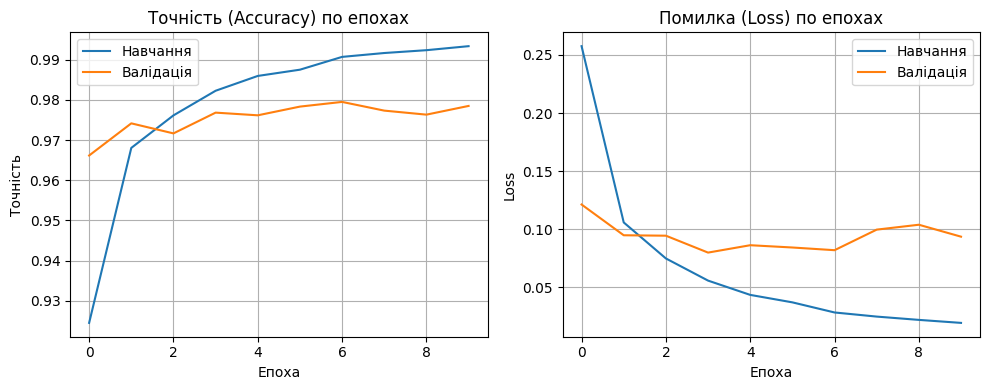


Всього помилок на 10,000 тестових зображень: 212


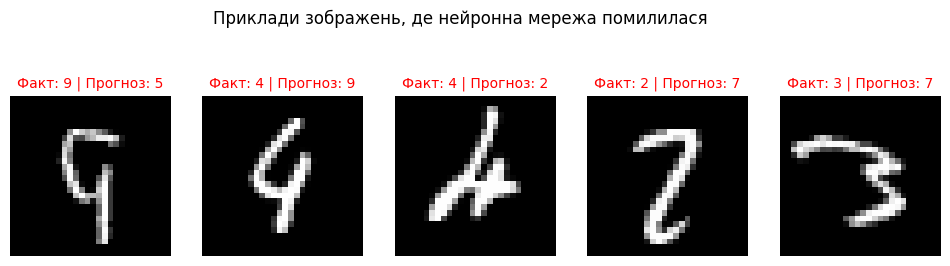

In [2]:
# ==============================================================================
# ЛАБОРАТОРНА РОБОТА №3: Навчання нейронної мережі для розпізнавання цифр (MNIST)
# ==============================================================================

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print(f"Версія TensorFlow: {tf.__version__}")

# 1. ЗАВАНТАЖЕННЯ ТА НОРМАЛІЗАЦІЯ ДАНИХ
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Нормалізація пікселів з [0, 255] до [0, 1]
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

print(f"Навчальна вибірка: {x_train_norm.shape[0]} зображень")
print(f"Тестова вибірка: {x_test_norm.shape[0]} зображень")

# 2. ПОБУДОВА ТА НАВЧАННЯ ПОКРАЩЕНОЇ МОДЕЛІ (З додатковим шаром та 10 епохами)
# Виконання завдань: +1 прихований шар (64 нейрони) та 10 епох навчання
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),          # Вхідний шар (28x28 -> 784)
    keras.layers.Dense(128, activation='relu'),          # Прихований шар 1 (128 нейронів)
    keras.layers.Dense(64, activation='relu'),           # Прихований шар 2 (64 нейрони) - Завдання 4
    keras.layers.Dense(10, activation='softmax')         # Вихідний шар (10 класів цифр 0-9)
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- СТРУКТУРА НЕЙРОННОЇ МЕРЕЖІ ---")
model.summary()

# Навчання моделі (10 епох)
history = model.fit(
    x_train_norm, y_train,
    epochs=10, batch_size=32,
    validation_split=0.1,
    verbose=1
)

# 3. ОЦІНКА ТОЧНОСТІ НА ТЕСТОВИХ ДАНИХ
test_loss, test_acc = model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\n✅ Точність на тестових даних: {test_acc * 100:.2f}%")
print(f"❌ Помилка (Loss): {test_loss:.4f}")

# 4. ГРАФІК ДИНАМІКИ НАВЧАННЯ
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Навчання')
plt.plot(history.history['val_accuracy'], label='Валідація')
plt.title('Точність (Accuracy) по епохах')
plt.xlabel('Епоха')
plt.ylabel('Точність')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Навчання')
plt.plot(history.history['val_loss'], label='Валідація')
plt.title('Помилка (Loss) по епохах')
plt.xlabel('Епоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. ПОШУК ТА ВІДОБРАЖЕННЯ ПРИКЛАДУ, ДЕ МЕРЕЖА ПОМИЛИЛАСЯ (Завдання 5)
predictions = model.predict(x_test_norm, verbose=0)
pred_labels = np.argmax(predictions, axis=1)

# Знаходимо індекси всіх неправильно розпізнаних цифр
errors_idx = np.where(pred_labels != y_test)[0]
print(f"\nВсього помилок на 10,000 тестових зображень: {len(errors_idx)}")

# Відображаємо перші 5 помилкових передбачень
plt.figure(figsize=(12, 3))
for idx, err_i in enumerate(errors_idx[:5]):
    plt.subplot(1, 5, idx + 1)
    plt.imshow(x_test[err_i], cmap='gray')
    plt.title(f"Факт: {y_test[err_i]} | Прогноз: {pred_labels[err_i]}", color='red', fontsize=10)
    plt.axis('off')
plt.suptitle('Приклади зображень, де нейронна мережа помилилася', fontsize=12, y=1.05)
plt.show()